In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
# Load Data
customers= pd.read_csv('Customer.csv')
products= pd.read_csv('prod_cat_info.csv')
transaction= pd.read_csv('Transactions.csv')

In [5]:
customers.head(3)

,customer_Id,DOB,Gender,city_code
0,268408,02-01-1970,M,4.0
1,269696,07-01-1970,F,8.0
2,268159,08-01-1970,F,8.0


In [7]:
products.head(3)

,prod_cat_code,prod_cat,prod_sub_cat_code,prod_subcat
0,1,Clothing,4,Mens
1,1,Clothing,1,Women
2,1,Clothing,3,Kids


In [9]:
transaction.head(3)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop


#### _Exploratory Data Analysis_

In [12]:
customers.shape, products.shape, transaction.shape

((5647, 4), (23, 4), (23053, 10))

In [14]:
customers['customer_Id'].nunique()

5647

In [16]:
transaction['cust_id'].nunique()

5506

In [18]:
customers.isnull().sum()

customer_Id    0
DOB            0
Gender         2
city_code      2
dtype: int64

In [20]:
customers.dropna(inplace=True)
customers.isnull().sum()

customer_Id    0
DOB            0
Gender         0
city_code      0
dtype: int64

In [22]:
products.isnull().sum()

prod_cat_code        0
prod_cat             0
prod_sub_cat_code    0
prod_subcat          0
dtype: int64

In [24]:
transaction.isnull().sum()

transaction_id      0
cust_id             0
tran_date           0
prod_subcat_code    0
prod_cat_code       0
Qty                 0
Rate                0
Tax                 0
total_amt           0
Store_type          0
dtype: int64

### Merge Datasets

In [27]:
products.rename(columns={'prod_sub_cat_code':'prod_subcat_code'}, inplace =True)

In [29]:
customer_final = pd.merge(transaction, customers, how='inner', right_on='customer_Id', left_on='cust_id')
customer_final = pd.merge(customer_final, products, how='inner', on=['prod_cat_code','prod_subcat_code'])

In [30]:
customer_final

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,prod_cat,prod_subcat
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,270351,26-09-1981,M,5.0,Clothing,Women
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,270384,11-05-1973,F,8.0,Electronics,Computers
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0,Books,DIY
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop,271509,08-06-1981,M,3.0,Home and kitchen,Bath
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0,Books,DIY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23031,94340757522,274550,25-01-2011,12,5,1,1264,132.720,1396.720,e-Shop,274550,21-02-1972,M,7.0,Books,Academic
23032,89780862956,270022,25-01-2011,4,1,1,677,71.085,748.085,e-Shop,270022,27-04-1984,M,9.0,Clothing,Mens
23033,85115299378,271020,25-01-2011,2,6,4,1052,441.840,4649.840,MBR,271020,20-06-1976,M,8.0,Home and kitchen,Furnishing
23034,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,270911,22-05-1970,M,2.0,Books,Children


In [33]:
customer_final.isnull().sum()

transaction_id      0
cust_id             0
tran_date           0
prod_subcat_code    0
prod_cat_code       0
Qty                 0
Rate                0
Tax                 0
total_amt           0
Store_type          0
customer_Id         0
DOB                 0
Gender              0
city_code           0
prod_cat            0
prod_subcat         0
dtype: int64

In [35]:
customer_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23036 entries, 0 to 23035
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    23036 non-null  int64  
 1   cust_id           23036 non-null  int64  
 2   tran_date         23036 non-null  object 
 3   prod_subcat_code  23036 non-null  int64  
 4   prod_cat_code     23036 non-null  int64  
 5   Qty               23036 non-null  int64  
 6   Rate              23036 non-null  int64  
 7   Tax               23036 non-null  float64
 8   total_amt         23036 non-null  float64
 9   Store_type        23036 non-null  object 
 10  customer_Id       23036 non-null  int64  
 11  DOB               23036 non-null  object 
 12  Gender            23036 non-null  object 
 13  city_code         23036 non-null  float64
 14  prod_cat          23036 non-null  object 
 15  prod_subcat       23036 non-null  object 
dtypes: float64(3), int64(7), object(6)
memor

In [37]:
customer_final['tran_date']= pd.to_datetime(customer_final['tran_date'], format='mixed', dayfirst=True)
customer_final['DOB']= pd.to_datetime(customer_final['DOB'], dayfirst=True)
customer_final['city_code']=customer_final['city_code'].astype('int64')

In [38]:
(customer_final['cust_id']== customer_final['customer_Id']).all()

True

In [41]:
customer_final.drop(columns=['customer_Id'], axis=1, inplace=True)

### SUMMARY REPORT

#### _Column names and their corresponding data types_

In [45]:
customer_final.dtypes

transaction_id               int64
cust_id                      int64
tran_date           datetime64[ns]
prod_subcat_code             int64
prod_cat_code                int64
Qty                          int64
Rate                         int64
Tax                        float64
total_amt                  float64
Store_type                  object
DOB                 datetime64[ns]
Gender                      object
city_code                    int64
prod_cat                    object
prod_subcat                 object
dtype: object

#### _Top/Bottom 10 observations_

In [48]:
top_10= customer_final.head(10)
bottom_10=customer_final.tail(10)

In [50]:
top_10

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,1981-09-26,M,5,Clothing,Women
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,1973-05-11,F,8,Electronics,Computers
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8,Books,DIY
3,93274880719,271509,2014-02-24,11,6,-3,-1363,429.345,-4518.345,e-Shop,1981-06-08,M,3,Home and kitchen,Bath
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8,Books,DIY
5,97439039119,272357,2014-02-23,8,3,-2,-824,173.040,-1821.040,TeleShop,1982-10-09,F,6,Electronics,Personal Appliances
6,45649838090,273667,2014-02-22,11,6,-1,-1450,152.250,-1602.250,e-Shop,1981-05-29,M,9,Home and kitchen,Bath
7,22643667930,271489,2014-02-22,12,6,-1,-1225,128.625,-1353.625,TeleShop,1971-04-21,M,9,Home and kitchen,Tools
8,79792372943,275108,2014-02-22,3,1,-3,-908,286.020,-3010.020,MBR,1971-11-04,F,8,Clothing,Kids
9,50076728598,269014,2014-02-21,8,3,-4,-581,244.020,-2568.020,e-Shop,1979-11-27,F,3,Electronics,Personal Appliances


In [52]:
bottom_10

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat
23026,49882891062,271982,2011-01-25,10,5,4,1330,558.600,5878.600,e-Shop,1976-08-10,M,8,Books,Non-Fiction
23027,14787475597,273982,2011-01-25,4,3,5,969,508.725,5353.725,e-Shop,1991-10-12,M,4,Electronics,Mobiles
23028,50691119572,273031,2011-01-25,6,5,1,1148,120.540,1268.540,TeleShop,1980-01-17,F,8,Books,DIY
23029,40893803228,272049,2011-01-25,11,6,3,1077,339.255,3570.255,e-Shop,1975-06-28,F,6,Home and kitchen,Bath
23030,30856003613,266866,2011-01-25,4,2,2,444,93.240,981.240,TeleShop,1974-04-18,M,4,Footwear,Kids
23031,94340757522,274550,2011-01-25,12,5,1,1264,132.720,1396.720,e-Shop,1972-02-21,M,7,Books,Academic
23032,89780862956,270022,2011-01-25,4,1,1,677,71.085,748.085,e-Shop,1984-04-27,M,9,Clothing,Mens
23033,85115299378,271020,2011-01-25,2,6,4,1052,441.840,4649.840,MBR,1976-06-20,M,8,Home and kitchen,Furnishing
23034,72870271171,270911,2011-01-25,11,5,3,1142,359.730,3785.730,TeleShop,1970-05-22,M,2,Books,Children
23035,77960931771,271961,2011-01-25,11,5,1,447,46.935,493.935,TeleShop,1982-01-15,M,1,Books,Children


In [54]:
customer_final.shape

(23036, 15)

#### “Five-number summary” for continuous variables (min, Q1, median, Q3 and max)

In [57]:
stats=customer_final[['Qty','Rate','Tax','total_amt']].describe()
stats[stats.index.isin(['min','25%','50%','75%','max'])]

,Qty,Rate,Tax,total_amt
min,-5.0,-1499.0,7.3500,-8270.925
25%,1.0,312.0,98.2800,762.450
50%,3.0,710.0,199.0800,1754.740
75%,4.0,1109.0,365.7675,3569.150
max,5.0,1500.0,787.5000,8287.500


#### Frequency tables for all the categorical variables

In [60]:
for col in customer_final.select_dtypes(include=['object']):
    print('-----------\n',col)
    print(customer_final[col].value_counts())

-----------
 Store_type
Store_type
e-Shop            9306
MBR               4659
Flagship store    4575
TeleShop          4496
Name: count, dtype: int64
-----------
 Gender
Gender
M    11805
F    11231
Name: count, dtype: int64
-----------
 prod_cat
prod_cat
Books               6064
Electronics         4894
Home and kitchen    4126
Footwear            2998
Clothing            2957
Bags                1997
Name: count, dtype: int64
-----------
 prod_subcat
prod_subcat
Women                  3046
Mens                   2911
Kids                   1995
Tools                  1062
Fiction                1042
Kitchen                1037
Children               1034
Mobiles                1031
Comics                 1031
Bath                   1021
Furnishing             1006
Non-Fiction            1002
DIY                     988
Cameras                 984
Personal Appliances     972
Academic                967
Computers               956
Audio and video         951
Name: count, dtype: int6

### Histograms for all continuous variables and frequency bars for categorical variables

In [63]:
customer_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23036 entries, 0 to 23035
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    23036 non-null  int64         
 1   cust_id           23036 non-null  int64         
 2   tran_date         23036 non-null  datetime64[ns]
 3   prod_subcat_code  23036 non-null  int64         
 4   prod_cat_code     23036 non-null  int64         
 5   Qty               23036 non-null  int64         
 6   Rate              23036 non-null  int64         
 7   Tax               23036 non-null  float64       
 8   total_amt         23036 non-null  float64       
 9   Store_type        23036 non-null  object        
 10  DOB               23036 non-null  datetime64[ns]
 11  Gender            23036 non-null  object        
 12  city_code         23036 non-null  int64         
 13  prod_cat          23036 non-null  object        
 14  prod_subcat       2303

In [65]:
customer_final['Qty'].unique()

array([-5, -2, -3, -1, -4,  5,  3,  4,  1,  2], dtype=int64)

In [67]:
num_cols=['Rate','Tax','total_amt']

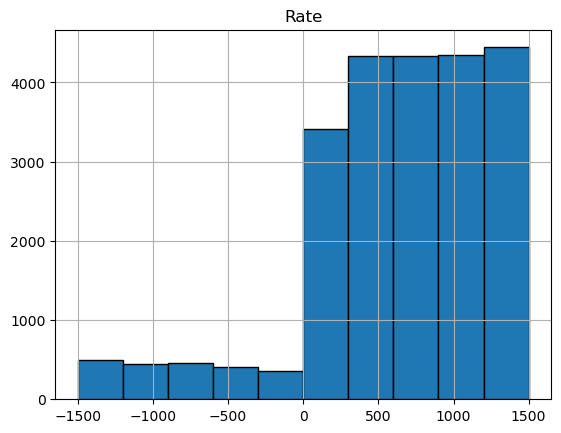

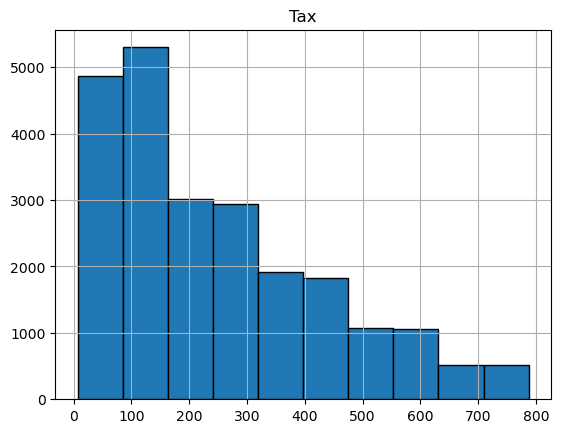

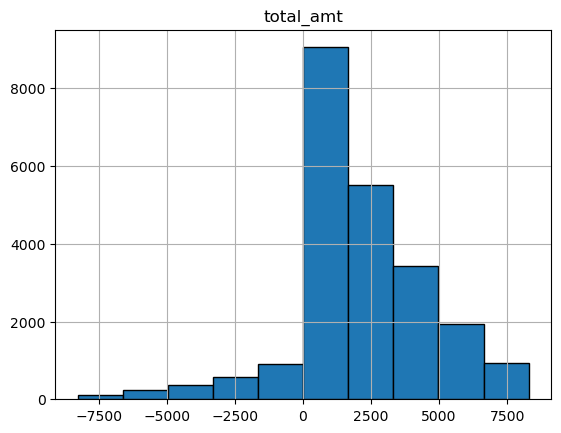

In [69]:
for col in num_cols:
    customer_final[col].hist(edgecolor='black')
    plt.title(col)
    plt.show()

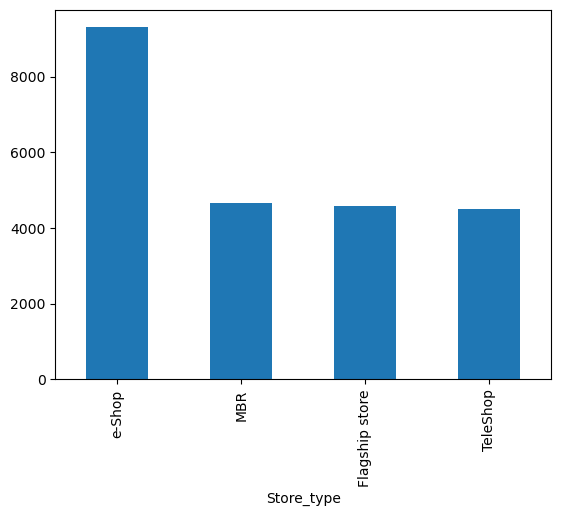

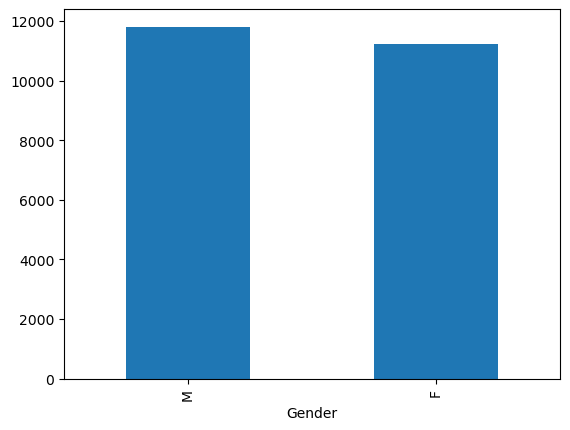

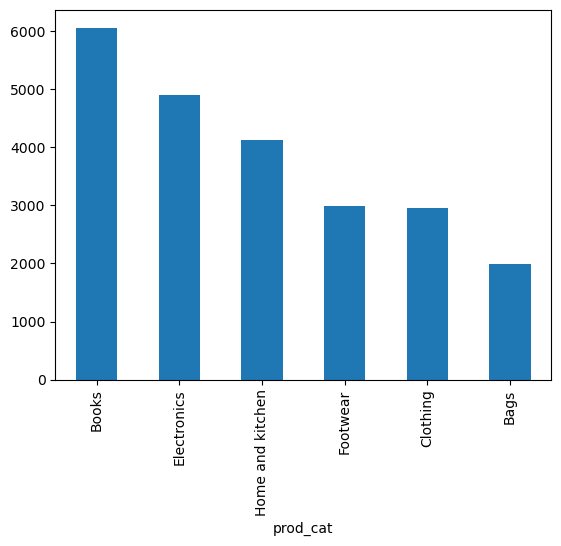

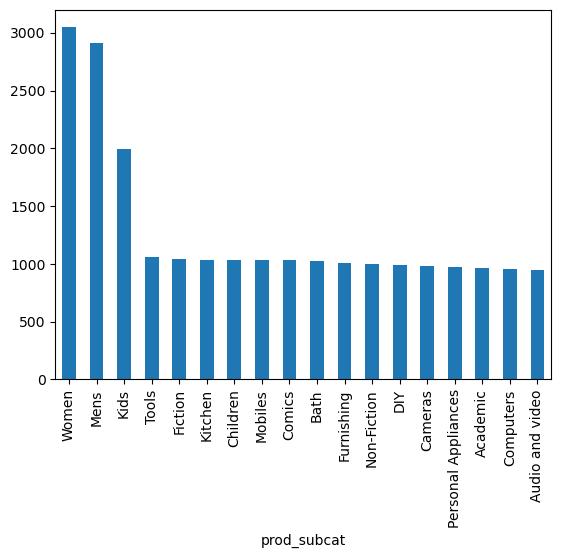

In [70]:
for col in customer_final.select_dtypes(include='object'):
    customer_final[col].value_counts().plot(kind='bar')
    plt.show()

### Key Analysis

#### a. Time period of transactions

In [74]:
print(customer_final['tran_date'].min(), 'to', customer_final['tran_date'].max())

2011-01-25 00:00:00 to 2014-02-28 00:00:00


#### b. Count of transactions where the total amount of transaction was negative

In [76]:
customer_final[customer_final['total_amt']<0].shape[0]

2176

### Category popularity (Male vs Female)

In [81]:
customer_final.head(2)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,1981-09-26,M,5,Clothing,Women
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,1973-05-11,F,8,Electronics,Computers


In [83]:
pd.pivot_table(customer_final, values='Qty', index='prod_cat', columns='Gender', aggfunc='sum')

Gender,F,M
prod_cat,,
Bags,2362,2345
Books,7070,7586
Clothing,3425,3748
Electronics,5827,6470
Footwear,3716,3555
Home and kitchen,4895,5036


### City with max customers

In [86]:
city_count=customer_final.groupby('city_code')['cust_id'].nunique().sort_values(ascending=False)
top_city=city_count.head(1)
percentage=(top_city.values[0]/ city_count.sum())*100
top_city, percentage


(city_code
 3    576
 Name: cust_id, dtype: int64,
 10.468920392584515)

### Store type performance

In [89]:
customer_final.groupby('Store_type').agg({'total_amt':'sum', 'Qty':'sum'}).sort_values(by='total_amt', ascending=False)

,total_amt,Qty
Store_type,,
e-Shop,1.982114e+07,22758
Flagship store,9.714802e+06,11131
MBR,9.667300e+06,11187
TeleShop,9.341038e+06,10959


#### Store with maximum value & Qty is e-shop.

### Revenue from Electronics & Clothing (Flagship-Store)

In [93]:
customer_final[(customer_final['Store_type']=='Flagship store') & (customer_final['prod_cat'].isin(['Electronics','Clothing']))]['total_amt'].sum()

3408936.0500000003

### Revenue from Male customers (Electronics)

In [96]:
customer_final[(customer_final['Gender']=='M') & (customer_final['prod_cat']=='Electronics')]['total_amt'].sum()

5697629.73

### Customers with >10 transactions (remove negative)

In [99]:
pos_tran=customer_final[customer_final['total_amt']>0]
tran_count= pos_tran.groupby('cust_id')['transaction_id'].nunique()
tran_count[tran_count>10].count()

6

### Age-based Analysis (25–35)

In [102]:
# Create age column
today= pd.to_datetime('today')
customer_final['Age']=(today-customer_final['DOB']).dt.days // 365
customer_final.head()

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat,Age
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,1981-09-26,M,5,Clothing,Women,44
1,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,1973-05-11,F,8,Electronics,Computers,52
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8,Books,DIY,33
3,93274880719,271509,2014-02-24,11,6,-3,-1363,429.345,-4518.345,e-Shop,1981-06-08,M,3,Home and kitchen,Bath,44
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8,Books,DIY,33


In [104]:
# Filter age group
age_grp_df= customer_final[(customer_final['Age']>=25) & (customer_final['Age']<=35)]

In [106]:
age_grp_df

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat,Age
2,51750724947,273420,2014-02-24,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8,Books,DIY,33
4,51750724947,273420,2014-02-23,6,5,-2,-791,166.110,-1748.110,TeleShop,1992-07-27,M,8,Books,DIY,33
28,88853694830,268444,2014-02-20,4,4,-3,-80,25.200,-265.200,MBR,1992-01-02,F,6,Bags,Women,34
37,31384765864,267058,2014-02-19,3,2,1,793,83.265,876.265,e-Shop,1992-02-06,F,10,Footwear,Women,34
59,83313344780,271288,2014-02-18,4,3,2,84,17.640,185.640,Flagship store,1991-02-25,F,3,Electronics,Mobiles,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22997,32904823908,269539,2011-01-26,1,4,4,455,191.100,2011.100,MBR,1992-03-20,F,7,Bags,Mens,34
23010,71176929896,269201,2011-01-26,8,3,5,295,154.875,1629.875,Flagship store,1991-03-02,M,9,Electronics,Personal Appliances,35
23015,90114483354,268097,2011-01-26,10,5,4,1408,591.360,6223.360,e-Shop,1992-12-15,F,7,Books,Non-Fiction,33
23018,42161597232,267094,2011-01-25,3,1,3,147,46.305,487.305,MBR,1992-11-24,M,9,Clothing,Kids,33


#### a. Spend on electronics & books

In [109]:
age_grp_df[age_grp_df['prod_cat'].isin(['Electronics','Books'])]['total_amt'].sum()

2571038.86

#### b. Spend between Jan 1 – Mar 1, 2014

In [112]:
age_grp_df[age_grp_df['tran_date'].between('2014-01-01','2014-03-01')]['total_amt'].sum()

284660.155

#### _Conclusion_
#### Customer purchasing behavior shows strong variation across categories, with certain store types and demographics contributing significantly to revenue.